#Taller N°2 de Minería de datos

Exploración de base de datos


In [1]:
# Importación de las librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Invocación de los datos
df_train = pd.read_excel('/content/drive/MyDrive/Minería de datos UNAB/Clase II/Taller II/Datos/cars.xlsx')
df_train.head(10)

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Lenght
0,Acura,MDX,SUV,Asia,All,36945,33337,3.5,6,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,23820,21761,2.0,4,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,26990,24647,2.4,4,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,33195,30299,3.2,6,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,43755,39014,3.5,6,225,18,24,3880,115,197
5,Acura,3.5 RL w/Navigation 4dr,Sedan,Asia,Front,46100,41100,3.5,6,225,18,24,3893,115,197
6,Acura,NSX coupe 2dr manual S,Sports,Asia,Rear,89765,79978,3.2,6,290,17,24,3153,100,174
7,Audi,A4 1.8T 4dr,Sedan,Europe,Front,25940,23508,1.8,4,170,22,31,3252,104,179
8,Audi,A41.8T convertible 2dr,Sedan,Europe,Front,35940,32506,1.8,4,170,23,30,3638,105,180
9,Audi,A4 3.0 4dr,Sedan,Europe,Front,31840,28846,3.0,6,220,20,28,3462,104,179


In [6]:
# Lista de las variables
df_train.columns

Index(['Make', 'Model', 'Type', 'Origin', 'DriveTrain', 'MSRP', 'Invoice',
       'EngineSize', 'Cylinders', 'Horsepower', 'MPG_City', 'MPG_Highway',
       'Weight', 'Wheelbase', 'Lenght'],
      dtype='object')

**Estructura de la Base de Datos**

Cada fila representa un automóvil, y las columnas incluyen:

* Make – Marca del automóvil (ej., Acura, Ford, Toyota).

*   Model – Modelo específico del automóvil.
*   Type – Tipo de automóvil (SUV, Sedan, etc.).
*  Origin – Región de origen del fabricante (ej., Asia, Europa, USA).
*  DriveTrain – Tipo de tracción (Front - delantera, Rear - trasera, All - tracción total).
* MSRP – Precio sugerido por el fabricante (Manufacturer's Suggested Retail Price).
* Invoice – Precio de factura (precio al que los concesionarios compran el vehículo al fabricante).
* EngineSize – Tamaño del motor en litros.
* Cylinders – Número de cilindros del motor.
* Horsepower – Potencia del motor en caballos de fuerza (HP).
* MPG_City – Rendimiento en millas por galón en ciudad.
* MPG_Highway – Rendimiento en millas por galón en carretera.
* Weight – Peso del automóvil en libras.
* Wheelbase – Distancia entre los ejes del vehículo en pulgadas.
* Length – Longitud total del vehículo en pulgadas.

In [7]:
# informacion de la base de datos
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         428 non-null    object 
 1   Model        428 non-null    object 
 2   Type         428 non-null    object 
 3   Origin       428 non-null    object 
 4   DriveTrain   428 non-null    object 
 5   MSRP         428 non-null    int64  
 6   Invoice      428 non-null    int64  
 7   EngineSize   428 non-null    float64
 8   Cylinders    423 non-null    object 
 9   Horsepower   428 non-null    int64  
 10  MPG_City     428 non-null    int64  
 11  MPG_Highway  428 non-null    int64  
 12  Weight       428 non-null    int64  
 13  Wheelbase    428 non-null    int64  
 14  Lenght       428 non-null    int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 50.3+ KB


In [8]:
# Resumen de estadísticos descriptivos
df_train.describe()

,MSRP,Invoice,EngineSize,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Lenght
count,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000
mean,32774.855140,30014.700935,3.196729,215.885514,20.060748,26.843458,3577.953271,108.154206,186.362150
std,19431.716674,17642.117750,1.108595,71.836032,5.238218,5.741201,758.983215,8.311813,14.357991
min,10280.000000,9875.000000,1.300000,73.000000,10.000000,12.000000,1850.000000,89.000000,143.000000
25%,20334.250000,18866.000000,2.375000,165.000000,17.000000,24.000000,3104.000000,103.000000,178.000000
50%,27635.000000,25294.500000,3.000000,210.000000,19.000000,26.000000,3474.500000,107.000000,187.000000
75%,39205.000000,35710.250000,3.900000,255.000000,21.250000,29.000000,3977.750000,112.000000,194.000000
max,192465.000000,173560.000000,8.300000,500.000000,60.000000,66.000000,7190.000000,144.000000,238.000000


In [9]:
# calculo del promedio
df_train['Invoice'].mean()

30014.70093457944

In [10]:
# calculo de la mediana
df_train['Invoice'].median()

25294.5

In [11]:
# calculo de la desviacion estandar
df_train['Invoice'].std()

17642.117750314763

In [12]:
# calculo de la varianza
df_train['Invoice'].var()

311244318.7159713

In [13]:
# calculo de la moda
df_train['Invoice'].mode()

,Invoice
0,14207
1,19638
2,68306


# Simetría y kurtosis
 La asimetría y curtosis informan sobre la forma de la distribución de una variable.

Asimetría negativa: la cola de la distribución se alarga para valores inferiores a la media.

Simétrica: hay el mismo número de elementos a izquierda y derecha de la media. En este caso, coinciden la media, la mediana y la moda. La distribución se adapta a la forma de la campana de Gauss, o distribución normal.
Asimetría positiva: la cola de la distribución se alarga (a la derecha) para valores superiores a la media.

 La curtosis (o apuntamiento) es una medida de forma que mide cuán escarpada o achatada está una curva o distribución.

In [15]:
print("Simetría: %f" % df_train['Invoice'].skew())
print("Kurtosis: %f" % df_train['Invoice'].kurt())

Simetría: 2.834740
Kurtosis: 13.946164


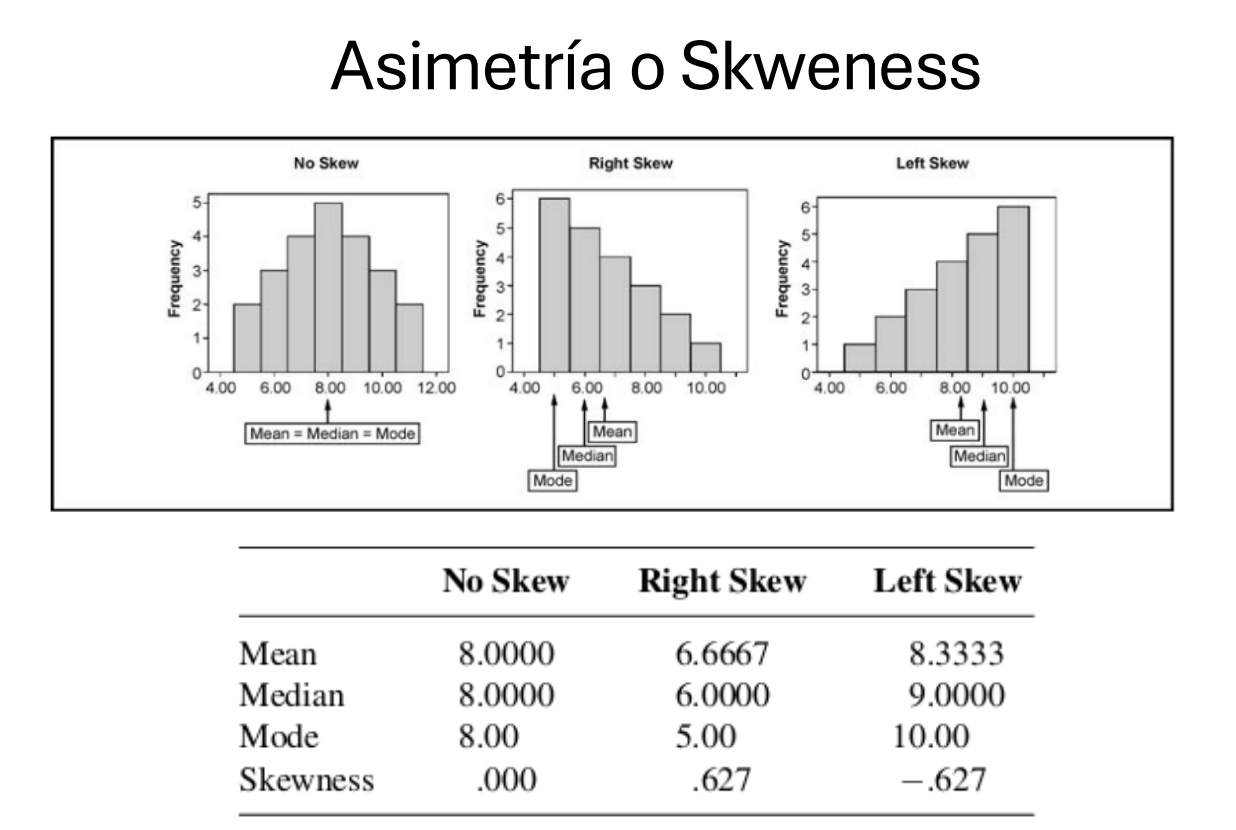

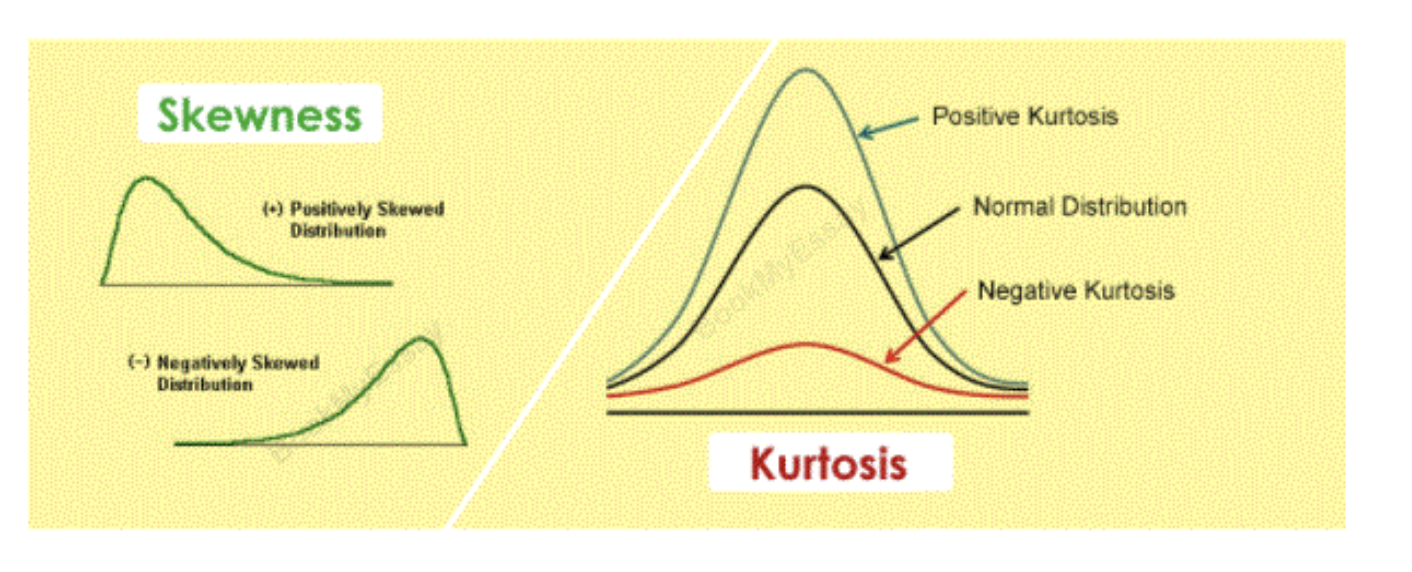

### **Correlacion de Pearson**

En estadística, el coeficiente de correlación de Pearson es una medida de dependencia lineal entre dos variables aleatorias cuantitativas. A diferencia de la covarianza, la correlación de Pearson es independiente de la escala de medida de las variables.

De manera menos formal, podemos definir el coeficiente de correlación de Pearson como un índice que puede utilizarse para medir el grado de relación de dos variables siempre y cuando ambas sean cuantitativas y continuas.


### **Correlacion de Spearman**

En las estadísticas , correlación de Spearman o de Spearman Rho , es una medida no paramétrica de dependencia estadística entre dos variables.

La correlación de Spearman se estudia cuando dos variables estadísticas parecen estar correlacionadas sin que la relación entre las dos variables sea de tipo afín . Consiste en encontrar un coeficiente de correlación, no entre los valores tomados por las dos variables sino entre los rangos de estos valores. Estima cuánto se puede describir la relación entre dos variables mediante una función monótona . Si no hay datos repetidos, se obtiene una correlación de Spearman perfecta de +1 o -1 cuando una de las variables es una función monótona perfecta de la otra.


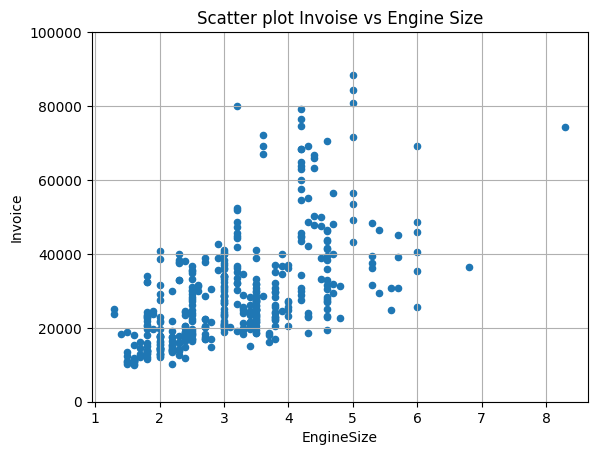

In [16]:
# Diagrama de dispersión para Invoice vs EngineSize
data = pd.concat([df_train['Invoice'], df_train['EngineSize']], axis=1)
fig, ax = plt.subplots()
data.plot.scatter(x='EngineSize', y='Invoice', ylim=(0,100000), ax = ax)
ax.set_title('Scatter plot Invoise vs Engine Size')
ax.grid(True)
plt.show()

In [17]:
print('El coeficiente de correlacion entre Invoice and EngineSize es ', np.corrcoef([df_train['Invoice'], df_train['EngineSize']])[0,1])

El coeficiente de correlacion entre Invoice and EngineSize es  0.5644979779575715


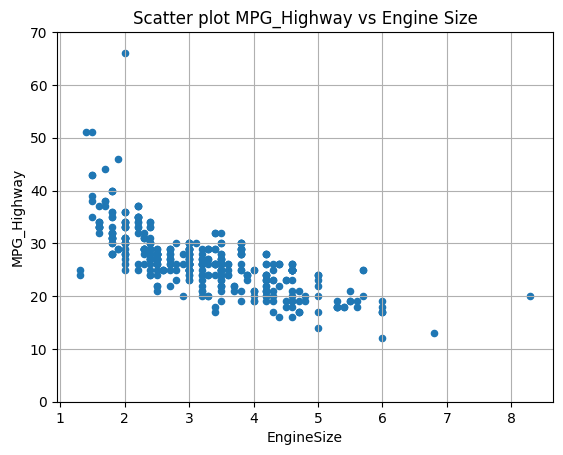

In [18]:
# Diagrama de dispersión para EngineSize vs MPG_Highway
var = 'EngineSize'
data = pd.concat([df_train['MPG_Highway'], df_train[var]], axis=1)
fig, ax = plt.subplots()
data.plot.scatter(x=var, y='MPG_Highway', ylim=(0,70), ax = ax);
ax.set_title('Scatter plot MPG_Highway vs Engine Size')
ax.grid(True)
plt.show()

In [19]:
print('El coeficiente de correlacion entre MPG_Highway and EngineSize es ', np.corrcoef([df_train['MPG_Highway'], df_train['EngineSize']])[0,1])

El coeficiente de correlacion entre MPG_Highway and EngineSize es  -0.7173016327383451


<function matplotlib.pyplot.show(close=None, block=None)>

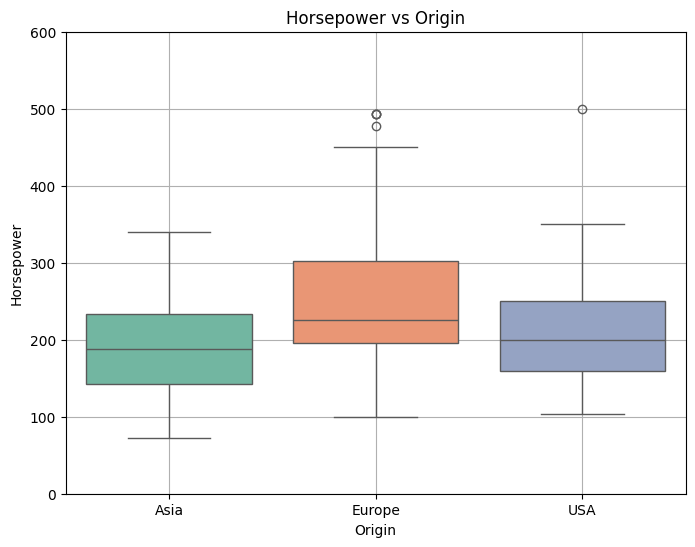

In [25]:
# Diagrama de caja para Horsepower vs Origin
var = 'Origin'
data = pd.concat([df_train['Horsepower'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
# Agregar colores con palette
sns.boxplot(x=var, y="Horsepower", data=data, ax=ax, palette="Set2")  # Cambia "Set2" por cualquier otra paleta de Seaborn
ax.set_title('Horsepower vs Origin')
ax.axis(ymin=0, ymax=600);
ax.grid(True)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

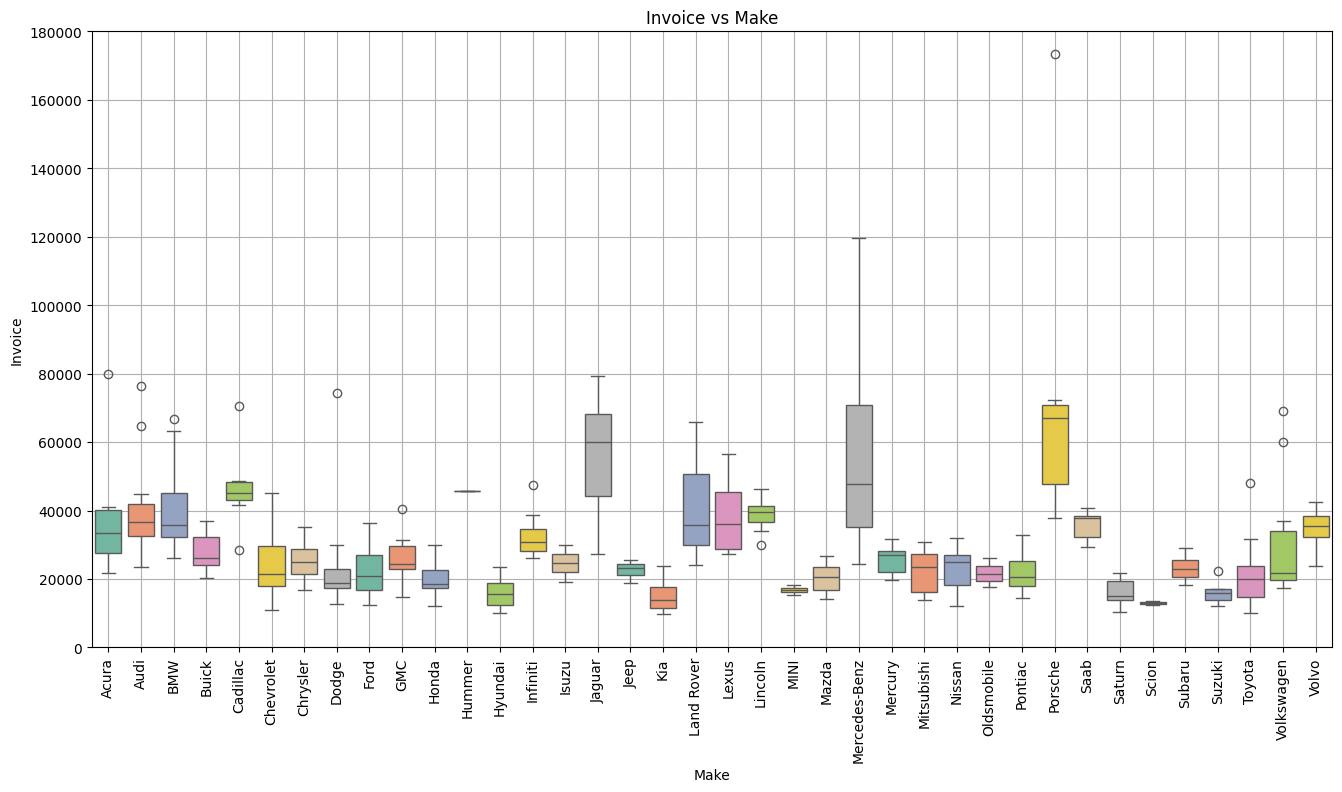

In [26]:
# Diagrama de caja para Invoice vs Make
var = 'Make'
data = pd.concat([df_train['Invoice'], df_train[var]], axis=1)

f, ax = plt.subplots(figsize=(16, 8))
sns.boxplot(x=var, y="Invoice", data=data, ax = ax, palette="Set2")
ax.set_title('Invoice vs Make')
ax.grid(True)
ax.axis(ymin=0, ymax=180000);
plt.xticks(rotation=90);
plt.show


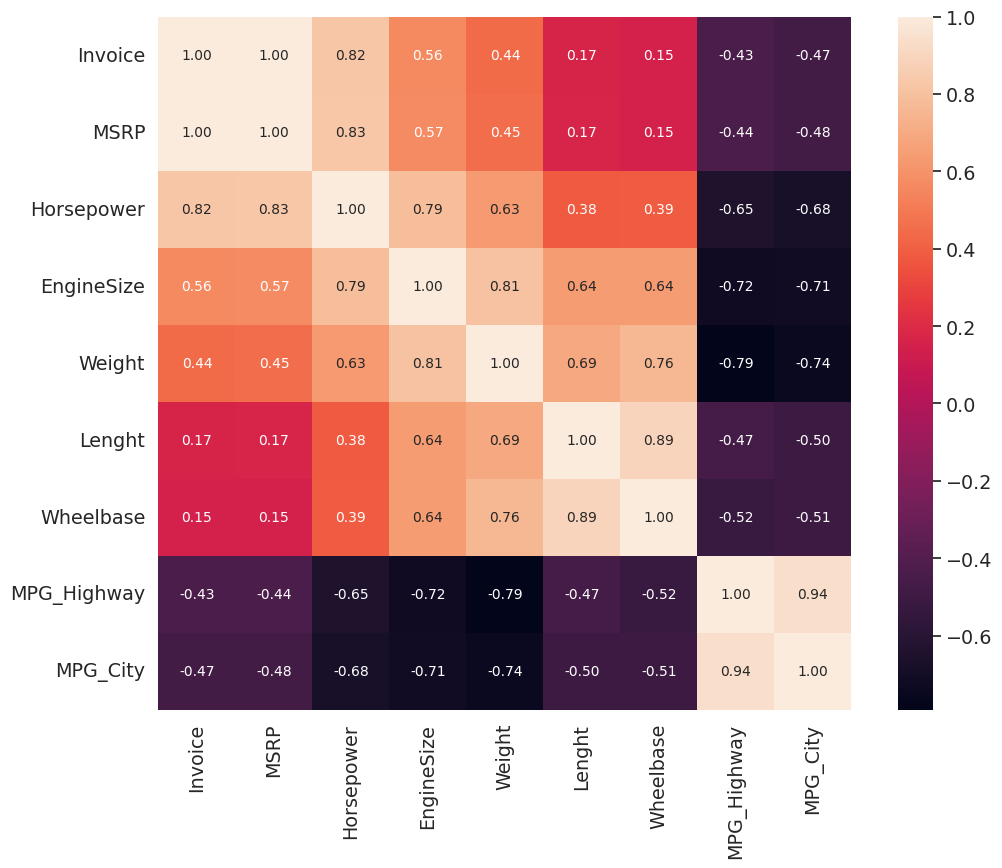

In [27]:
# Filtrar solo columnas numéricas
df_numeric = df_train.select_dtypes(include=['number'])

# Calcular matriz de correlación
corrmat = df_numeric.corr()

# Seleccionar las k variables más correlacionadas con 'Invoice'
k = min(10, len(corrmat.columns))  # Ajusta k para no exceder el número de columnas disponibles
if 'Invoice' in corrmat:
    cols = corrmat.nlargest(k, 'Invoice')['Invoice'].index
else:
    cols = corrmat.columns[:k]  # Si no existe 'Invoice', selecciona las primeras k variables

# Matriz de correlación de las variables seleccionadas
cm = np.corrcoef(df_numeric[cols].values.T)

# Configurar el mapa de calor
sns.set(font_scale=1.25)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
            yticklabels=cols.values, xticklabels=cols.values)

plt.show()

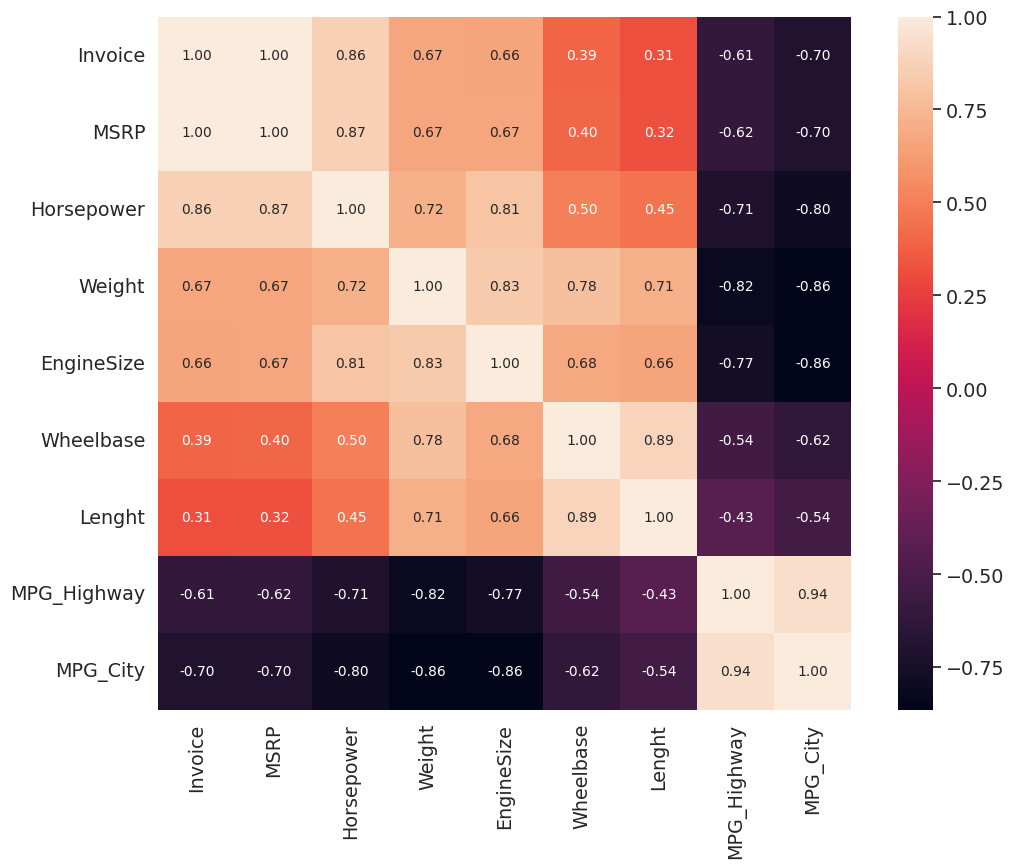

In [29]:
from scipy.stats import spearmanr
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar solo columnas numéricas
df_numeric = df_train.select_dtypes(include=['number'])

# Calcular la matriz de correlación de Spearman
corrmat = df_numeric.corr(method='spearman')

# Definir la cantidad de variables a visualizar
k = min(10, len(corrmat.columns))  # Ajusta k si hay menos de 10 variables numéricas

# Verificar si 'Invoice' está en las columnas numéricas
if 'Invoice' in corrmat:
    cols = corrmat.nlargest(k, 'Invoice')['Invoice'].index  # Seleccionar las k más correlacionadas con Invoice
else:
    cols = corrmat.columns[:k]  # Si no existe 'Invoice', selecciona las primeras k variables

# Matriz de correlación de Spearman
rho, pval = spearmanr(df_numeric[cols].values, axis=0)

# Crear el heatmap con Seaborn
sns.set(font_scale=1.25)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(rho, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
            yticklabels=cols.values, xticklabels=cols.values)

plt.show()


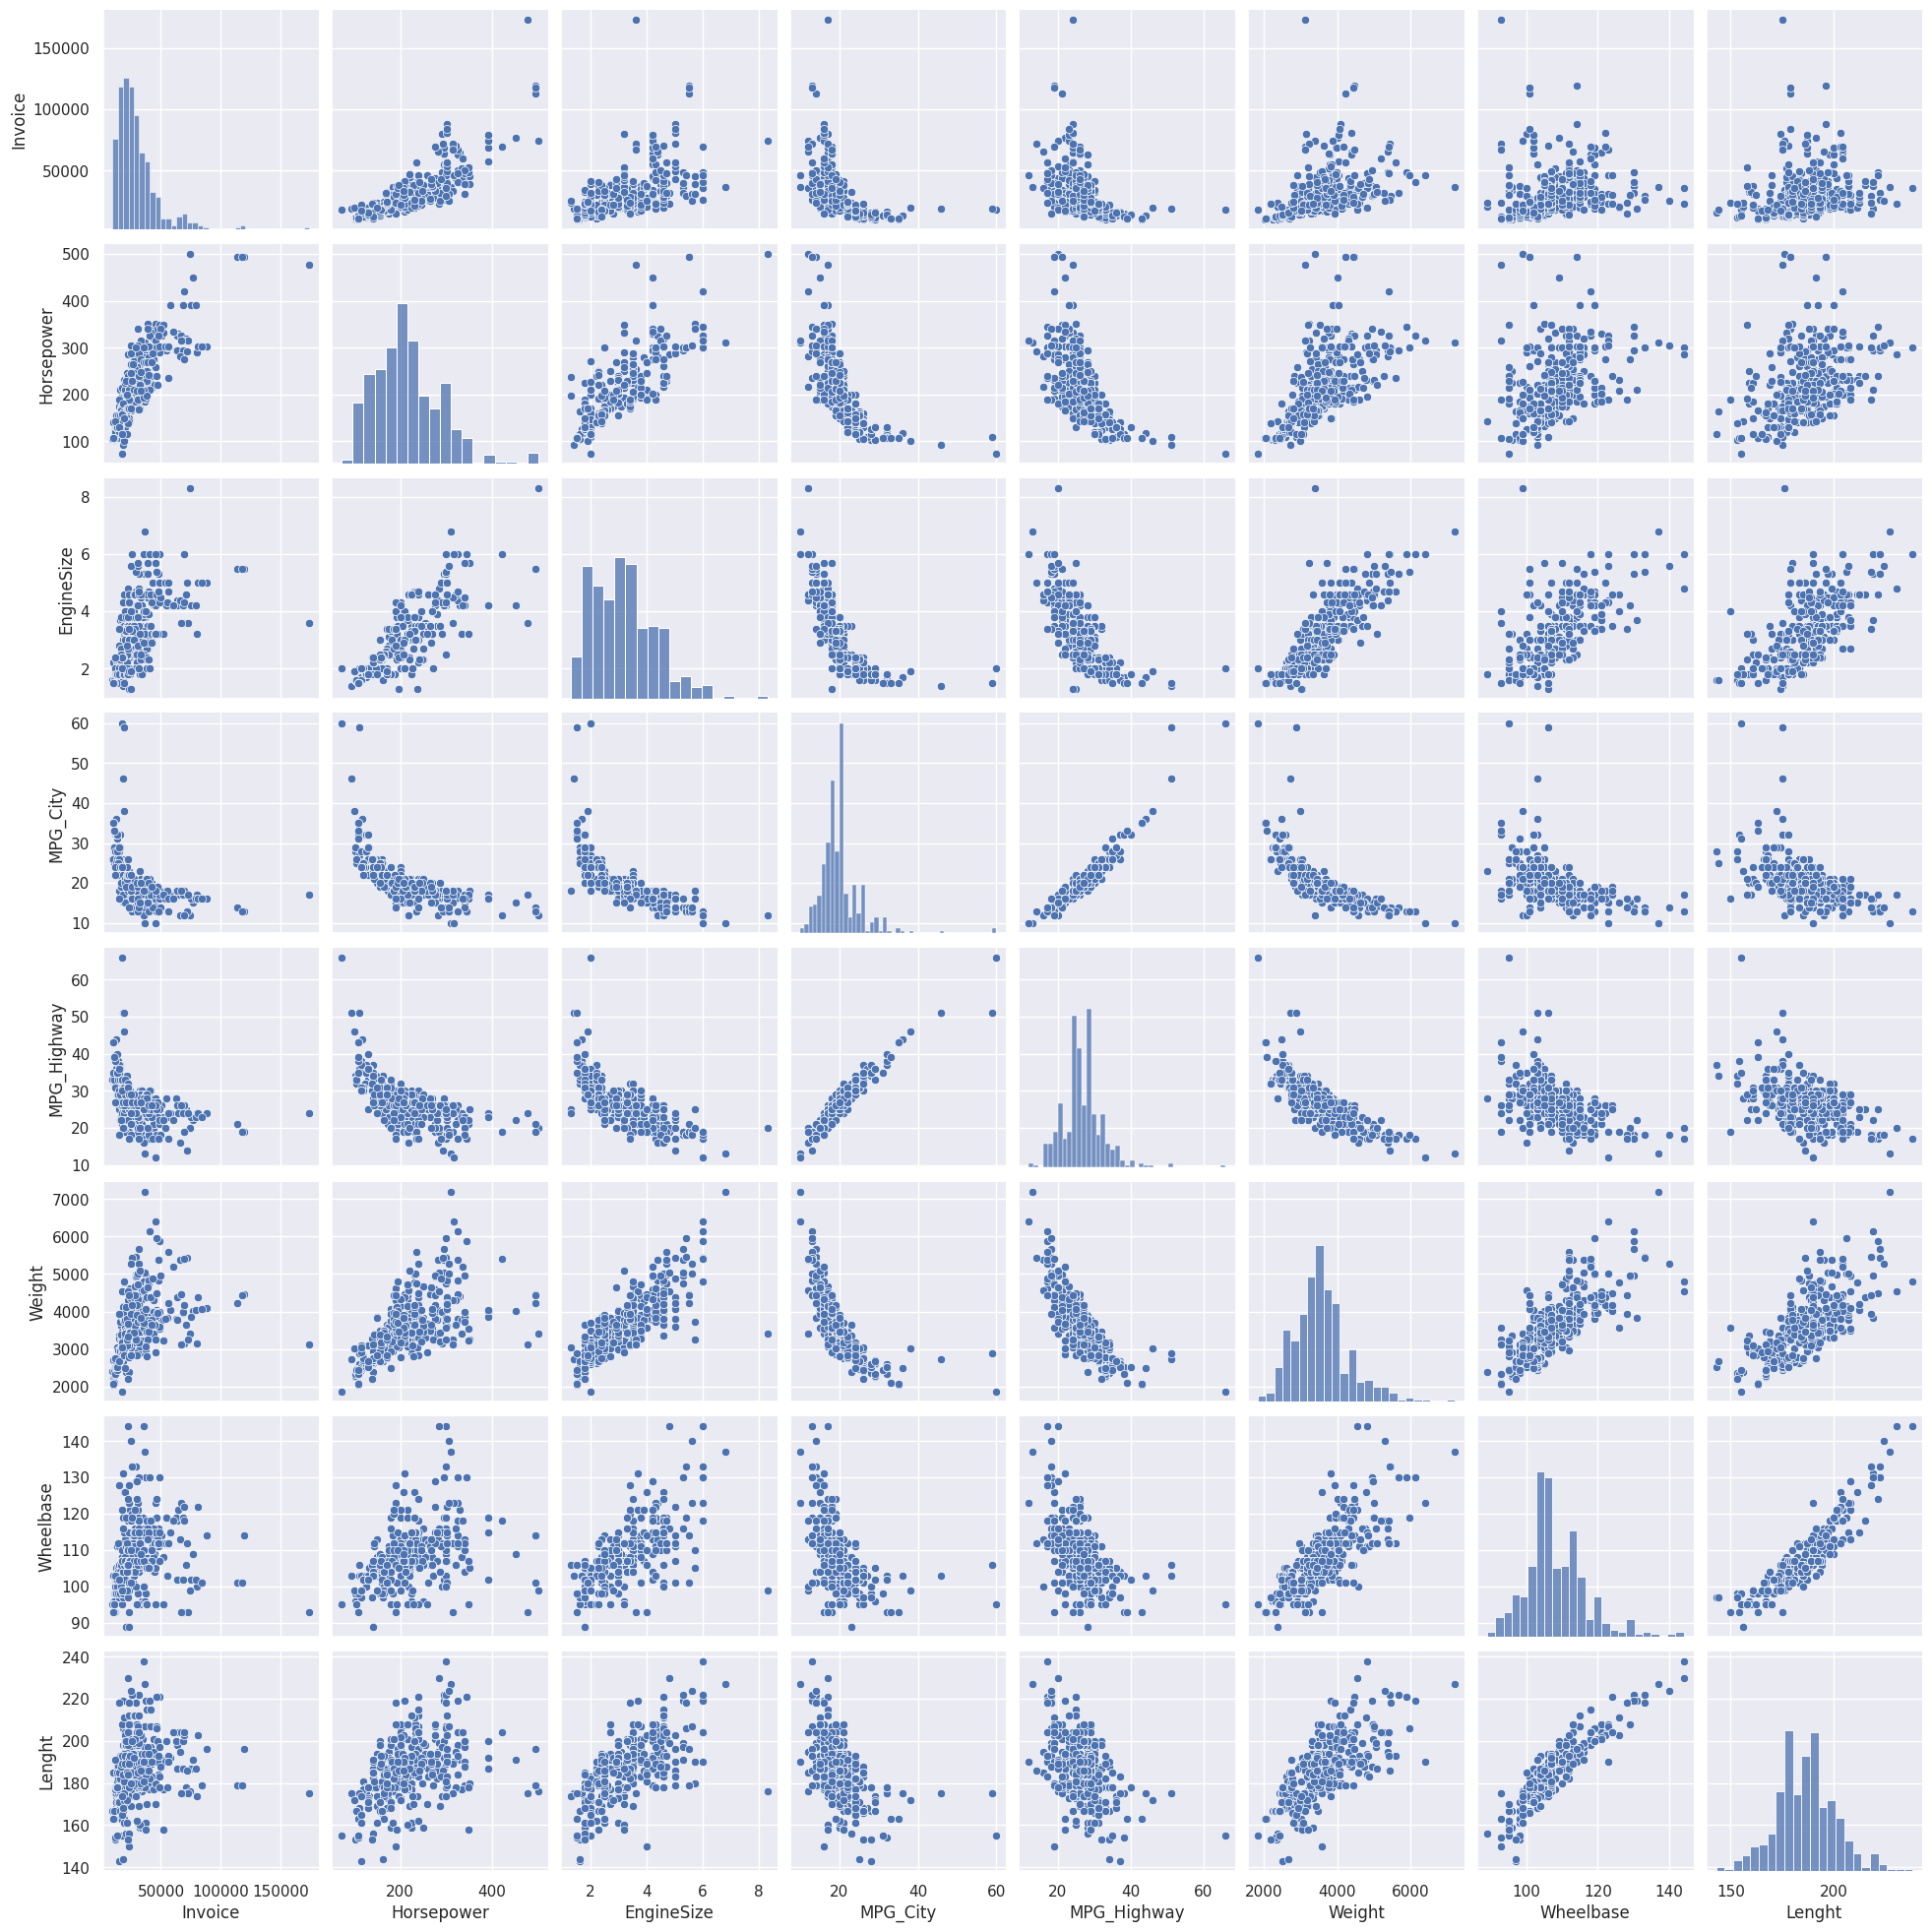

In [30]:
# Diagramas de dispersión
sns.set()
cols = ['Invoice', 'Horsepower', 'EngineSize', 'MPG_City', 'MPG_Highway', 'Weight', 'Wheelbase', 'Lenght']
sns.pairplot(df_train[cols], size = 2.5)
plt.show();

In [31]:
# Datos perdidos
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
Cylinders,5,0.011682
Make,0,0.000000
Model,0,0.000000
Type,0,0.000000
Origin,0,0.000000
DriveTrain,0,0.000000
MSRP,0,0.000000
Invoice,0,0.000000
EngineSize,0,0.000000
Horsepower,0,0.000000


In [33]:
# Tratamiento de datos perdidos
df_train = df_train.drop(missing_data[missing_data['Total'] > 1].index, axis=1)#Filtra las filas donde la columna 'Total' sea mayor a 1 (es decir, columnas con más de 1 dato perdido).

print(df_train.isnull().sum().max())  # Debería devolver 0 si no hay valores nulos


0


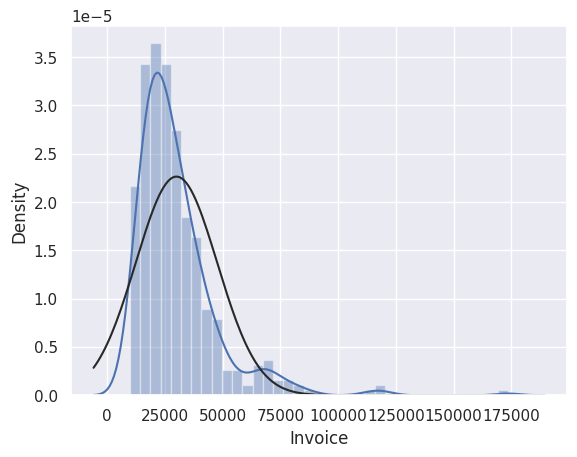

In [34]:
# Exámen de distribución de los datos
fig, ax = plt.subplots()
sns.distplot(df_train['Invoice'], fit=norm);
plt.show()


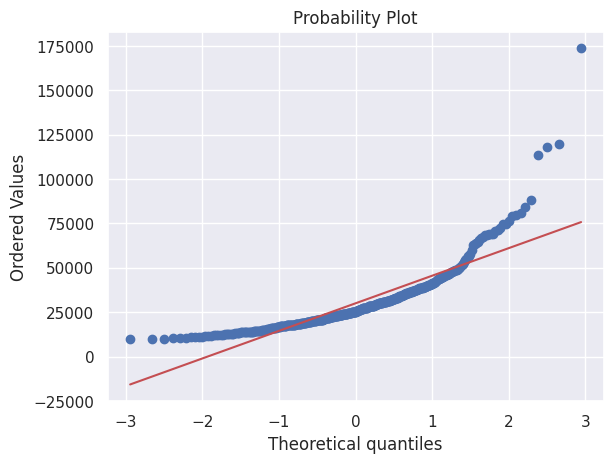

In [35]:
# Genera una gráfica de probabilidad de datos de muestra contra los cuantiles de
# una distribución teórica específica (la distribución normal por defecto).
# probplot calcula opcionalmente una línea de mejor ajuste para los datos y
# traza los resultados usando Matplotlib o una función de trazado dada.
fig, ax = plt.subplots()
res = stats.probplot(df_train['Invoice'], plot=plt)
plt.show()


In [36]:
# Aplicando transformación logarítmica
df_train['Invoice'] = np.log(df_train['Invoice'])

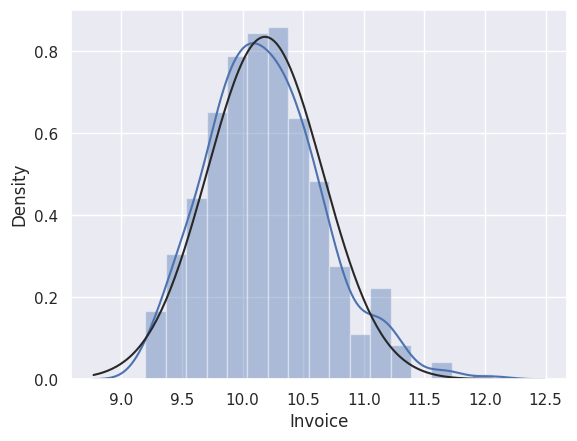

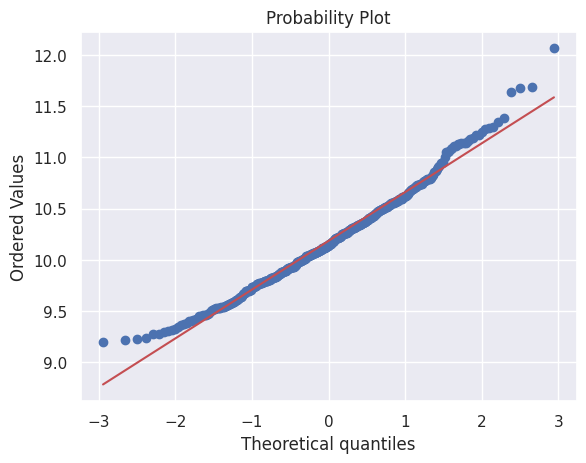

In [37]:
# Exámen de la distribución de los datos transformados
sns.distplot(df_train['Invoice'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['Invoice'], plot=plt)

Analíticas de bondad de ajuste a la distribución normal.
Probar si "invoice" tiene o no distribución normal, con base en alguna prueba analítica de bondad de ajuste.

Ejemplo: Anderson-Darling / Wilk-Shapiro / Jarque-Bera

En estadística, el Test de Shapiro–Wilk se usa para contrastar la normalidad de un conjunto de datos. Se plantea como hipótesis nula (H0) que una muestra proviene de una población normalmente distribuida, y como hipotesis alternativa (H1) que la muestra no posee una distribucion normal.

El test de Wilk-Shapiro, entrega un estadistico W el cual oscila entre [0-1] y un p-value. Si la distribucion de la muestra no es normal, el p-value sera menor que alpha = 0.05, en caso contrario el p-value será mayor que alpha = 0.05.

In [38]:
alpha = 0.05 # asignamos un valor para la significancia estadistica.

# Analizamos los valores originales de Invoice
print('Analizando Invoice sin Transformar')
shapiro_test = stats.shapiro(df_train['Invoice']) # aplico el tes de wilk-shapiro a Invoice
print('p-value = %.4f' % (shapiro_test[1])) # imprimo el valor W y el p-value calculado
# muestro el resultado encontrado
if shapiro_test[1]>alpha:
    print('No se puede rechazar la hipotesis nula: Los datos distribuyen normal')
else:
    print('Se rechaza la hipotesis nula: Los datos no distribuyen normal')

# Transformamos los valores de Invoice para que podamos evaluar si cambia la
# distribución aplicando una transformación logarítmica a los datos.
print('')
print('Aplicando transformación logarítmica')
shapiro_test = stats.shapiro(np.log(df_train['Invoice'])) # aplico el tes de wilk-shapiro a cada una de las variables j aplicando transformacion logaritmica
print('p-value = %.4f' % (shapiro_test[1])) # imprimo el valor W y el p-value calculado
# muestro el resultado encontrado
if shapiro_test[1]>alpha:
    print('No se puede rechazar la hipotesis nula: Los datos distribuyen normal')
else:
    print('Se rechaza la hipotesis nula: Los datos no distribuyen normal')

# Podemos ver según los resultados que la variable invoice no posee una distribución normal.
# Al aplicar transformación logarítmica se mantienen las mismas conclusiones.

Analizando Invoice sin Transformar
p-value = 0.0001
Se rechaza la hipotesis nula: Los datos no distribuyen normal

Aplicando transformación logarítmica
p-value = 0.0043
Se rechaza la hipotesis nula: Los datos no distribuyen normal


Trabajo autónomo del estudiante

* ¿Qué marcas y modelos tienen el mejor rendimiento de combustible?
* ¿Cómo se relaciona la potencia del motor con el consumo de gasolina?
* ¿Cuál es la diferencia de precio entre los distintos tipos de automóviles?
* ¿Existen tendencias en el tamaño de los motores según el país de origen?
* ¿Cómo influye el peso del vehículo en su eficiencia de combustible?